In [22]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.optimize import minimize
from sklearn.linear_model import LinearRegression
import seaborn as sns
import warnings
import time

warnings.filterwarnings("ignore")

In [25]:
# Important to use the same Kernel as the YAC Univariate Analysis
df = pd.read_parquet('data.parquet')
print(len(df))
df = df.loc[df['play_type']=='pass']
print(len(df))

104940
104940


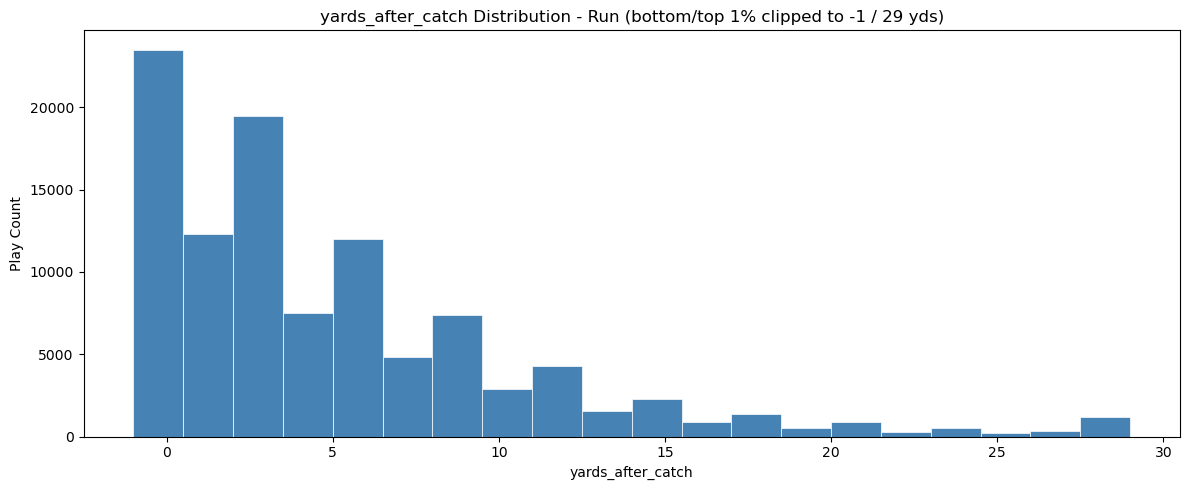

In [26]:
temp = df.copy()

low = temp['yards_after_catch'].quantile(0.01)
high = temp['yards_after_catch'].quantile(0.99)

clipped = temp['yards_after_catch'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('yards_after_catch')
ax.set_ylabel('Play Count')
ax.set_title(f'yards_after_catch Distribution - Run (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

## Distribution Selection

In [48]:
# Single column (1D array)
YAC_arr_1d = df['yards_after_catch'].to_numpy()
# Remove NaN values
YAC_arr_1d = YAC_arr_1d[~np.isnan(YAC_arr_1d)] 

print(f"YAC plays after filtering: {len(yards):,}")
print(f"  Mean:   {np.mean(YAC_arr_1d):.2f} yds")
print(f"  Median: {np.median(YAC_arr_1d):.2f} yds")
print(f"  Std:    {np.std(YAC_arr_1d):.2f} yds")
print(f"  Min:    {np.min(YAC_arr_1d):.0f} yds  Max: {np.max(YAC_arr_1d):.0f} yds")

YAC plays after filtering: 104,326
  Mean:   5.04 yds
  Mean:   5.04 yds
  Median: 3.00 yds
  Std:    6.27 yds
  Min:    -13 yds  Max: 80 yds


In [40]:
DISTRIBUTIONS = {
    "Normal":           stats.norm,
    "Skew-Normal":      stats.skewnorm,
    "Johnson SU":       stats.johnsonsu,
    "Gen. Normal":      stats.gennorm,
    "Laplace":          stats.laplace,
    "Skew-t":           stats.nct,
    "NIG":              stats.norminvgauss,
    "Gen. Hyperbolic":  stats.genhyperbolic,
    "Asym. Laplace":    stats.laplace_asymmetric,
}

In [49]:
def fit_distribution(dist, data):
    """Fit a scipy distribution and return params + diagnostics."""
    params = dist.fit(data)
    log_lik = np.sum(dist.logpdf(data, *params))
    k = len(params)
    n = len(data)
    aic = 2 * k - 2 * log_lik
    bic = k * np.log(n) - 2 * log_lik
    ks_stat, ks_p = stats.kstest(data, dist.cdf, args=params)
    return {
        "params": params,
        "log_lik": log_lik,
        "aic": aic,
        "bic": bic,
        "ks_stat": ks_stat,
        "ks_p": ks_p,
    }

results = {}
for name, dist in DISTRIBUTIONS.items():
    print(f"Fitting {name}...", end=" ")
    res = fit_distribution(dist, YAC_arr_1d)
    results[name] = res
    print(f"AIC={res['aic']:.1f}  BIC={res['bic']:.1f}  KS={res['ks_stat']:.4f}")

Fitting Normal... AIC=679110.7  BIC=679129.9  KS=0.1980
Fitting Skew-Normal... AIC=613536.3  BIC=613564.9  KS=0.1797
Fitting Johnson SU... AIC=-120342.2  BIC=-120304.0  KS=0.6765
Fitting Gen. Normal... AIC=646155.1  BIC=646183.8  KS=0.2125
Fitting Laplace... AIC=648125.1  BIC=648144.3  KS=0.2282
Fitting Skew-t... AIC=591833.4  BIC=591871.6  KS=0.1298
Fitting NIG... AIC=587338.5  BIC=587376.7  KS=0.1275
Fitting Gen. Hyperbolic... AIC=321618.9  BIC=321666.7  KS=0.7292
Fitting Asym. Laplace... AIC=571926.4  BIC=571955.1  KS=0.1672


In [50]:
summary = pd.DataFrame({
    name: {
        "Log-Likelihood": f"{r['log_lik']:.1f}",
        "AIC":            f"{r['aic']:.1f}",
        "BIC":            f"{r['bic']:.1f}",
        "KS Statistic":   f"{r['ks_stat']:.4f}",
        "KS p-value":     f"{r['ks_p']:.4f}",
    }
    for name, r in results.items()
}).T

print("\n── Distribution Comparison ──────────────────────────────────────────")
print(summary.to_string())

best_aic = min(results, key=lambda n: results[n]["aic"])
best_bic = min(results, key=lambda n: results[n]["bic"])
best_ks  = min(results, key=lambda n: results[n]["ks_stat"])
print(f"\n  Best AIC: {best_aic}")
print(f"  Best BIC: {best_bic}")
print(f"  Best KS:  {best_ks}")


── Distribution Comparison ──────────────────────────────────────────
                Log-Likelihood        AIC        BIC KS Statistic KS p-value
Normal               -339553.4   679110.7   679129.9       0.1980     0.0000
Skew-Normal          -306765.1   613536.3   613564.9       0.1797     0.0000
Johnson SU             60175.1  -120342.2  -120304.0       0.6765     0.0000
Gen. Normal          -323074.6   646155.1   646183.8       0.2125     0.0000
Laplace              -324060.6   648125.1   648144.3       0.2282     0.0000
Skew-t               -295912.7   591833.4   591871.6       0.1298     0.0000
NIG                  -293665.3   587338.5   587376.7       0.1275     0.0000
Gen. Hyperbolic      -160804.4   321618.9   321666.7       0.7292     0.0000
Asym. Laplace        -285960.2   571926.4   571955.1       0.1672     0.0000

  Best AIC: Johnson SU
  Best BIC: Johnson SU
  Best KS:  NIG


In [52]:
COLORS = {
    "Normal":       "#4e79a7",
    "Skew-Normal":  "#f28e2b",
    "Johnson SU":   "#e15759",
    "Gen. Normal":  "#76b7b2",
    "Laplace":      "#59a14f",
    "Skew-t":           "#e377c2",
    "NIG":              "#8c564b",
    "Gen. Hyperbolic":  "#bcbd22",
    "Asym. Laplace":    "#17becf",
}

Filtered out distributions that do not look reasonable


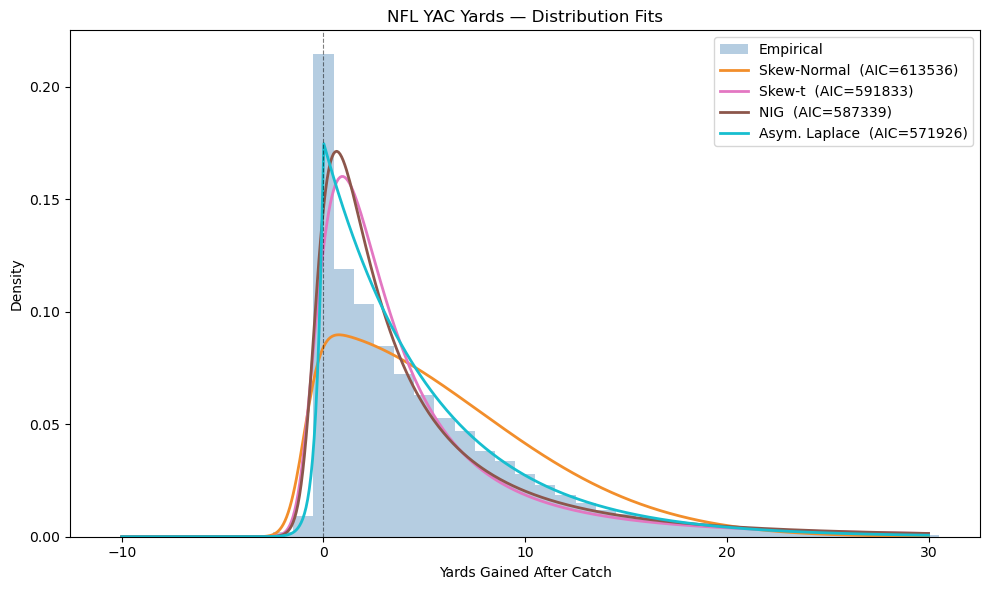

In [63]:
clip = (-10, 30)
yac_clipped = YAC_arr_1d[(YAC_arr_1d >= clip[0]) & (YAC_arr_1d <= clip[1])]
x_range = np.linspace(clip[0], clip[1], 500)
bins = np.arange(clip[0], clip[1] + 2) - 0.5

fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(yac_clipped, bins=bins, density=True,
        color="steelblue", alpha=0.4, label="Empirical")

exclusion_list = ["dummy"
    ,"Normal"
#    ,"Skew-Normal"
    ,"Johnson SU"
    ,"Gen. Normal"
    ,"Laplace"
#    ,"Skew-t"
#    ,"NIG"
    ,"Gen. Hyperbolic"
#    ,"Asym. Laplace"
]

print('Filtered out distributions that do not look reasonable')
for name, dist in DISTRIBUTIONS.items():
    #if name not in ['Normal','Gen. Normal','Skew-Normal','Laplace','Asym. Laplace']:
    if name not in exclusion_list:    
        params = results[name]["params"]
        pdf_vals = dist.pdf(x_range, *params)
        ax.plot(x_range, pdf_vals, color=COLORS[name], linewidth=2,
                label=f"{name}  (AIC={results[name]['aic']:.0f})")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("NFL YAC Yards — Distribution Fits")
ax.set_xlabel("Yards Gained After Catch")
ax.set_ylabel("Density")
ax.legend()
plt.tight_layout()
plt.show()

Filtered out distributions that do not look reasonable


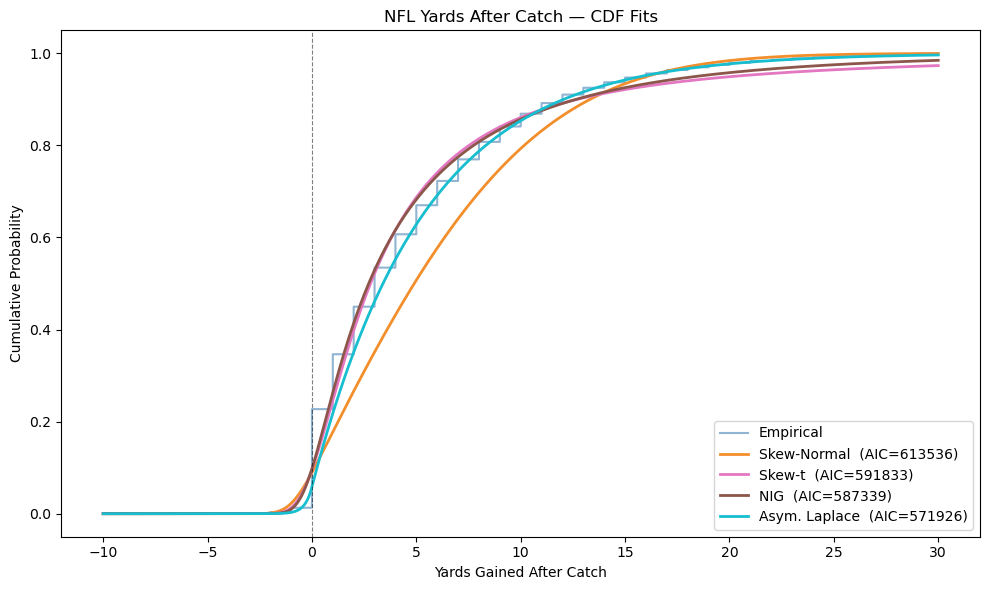

In [64]:
clip = (-10, 30)
yac_clipped = YAC_arr_1d[(YAC_arr_1d >= clip[0]) & (YAC_arr_1d <= clip[1])]
x_range = np.linspace(clip[0], clip[1], 500)

fig, ax = plt.subplots(figsize=(10, 6))

# Empirical CDF
ecdf_x = np.sort(yac_clipped)
ecdf_y = np.arange(1, len(ecdf_x) + 1) / len(ecdf_x)
ax.step(ecdf_x, ecdf_y, color="steelblue", alpha=0.6, linewidth=1.5, label="Empirical")
print('Filtered out distributions that do not look reasonable')
for name, dist in DISTRIBUTIONS.items():
    if name not in exclusion_list:
        params = results[name]["params"]
        cdf_vals = dist.cdf(x_range, *params)
        ax.plot(x_range, cdf_vals, color=COLORS[name], linewidth=2,
                label=f"{name}  (AIC={results[name]['aic']:.0f})")

ax.axvline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.5)
ax.set_title("NFL Yards After Catch — CDF Fits")
ax.set_xlabel("Yards Gained After Catch")
ax.set_ylabel("Cumulative Probability")
ax.legend()
plt.tight_layout()
plt.show()

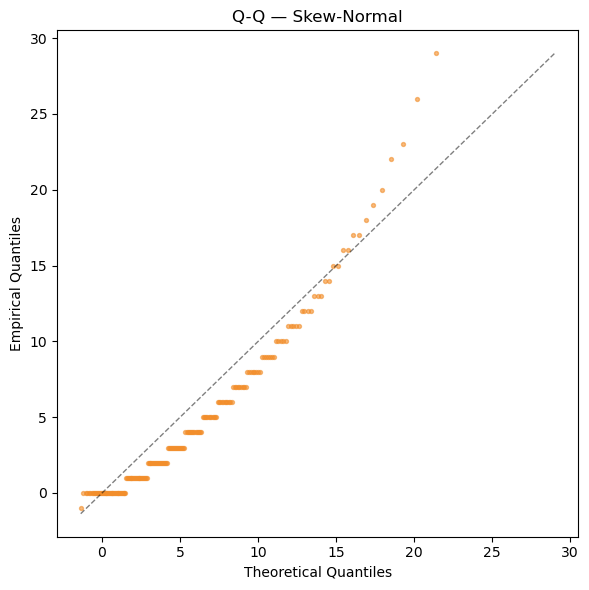

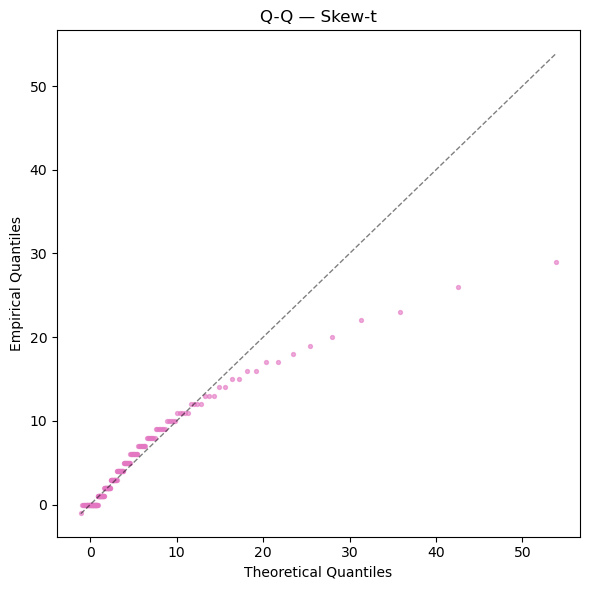

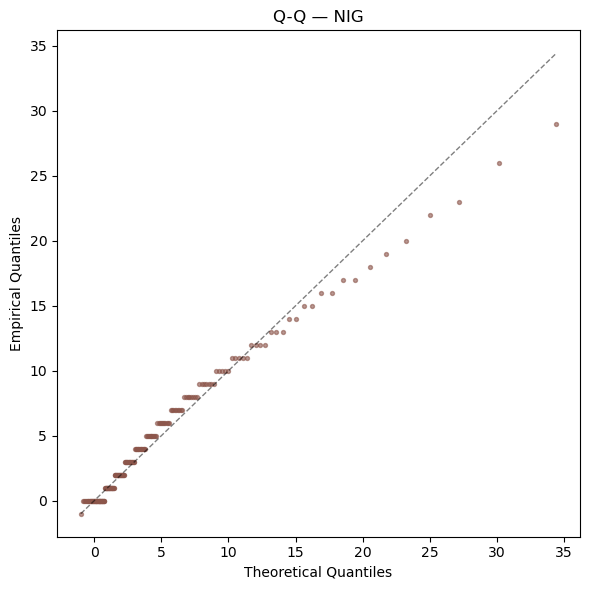

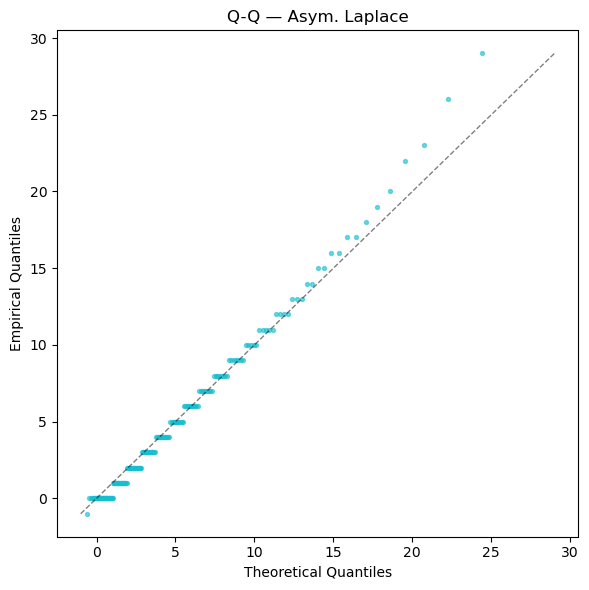

In [65]:
filtered = [name for name in DISTRIBUTIONS if name not in exclusion_list]
#filtered = [name for name in DISTRIBUTIONS]
percentiles = np.linspace(1, 99, 200)
empirical_q = np.percentile(YAC_arr_1d, percentiles)

for name in filtered:
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    dist = DISTRIBUTIONS[name]
    params = results[name]["params"]
    theoretical_q = dist.ppf(percentiles / 100, *params)

    ax.scatter(theoretical_q, empirical_q, color=COLORS[name], s=8, alpha=0.6)
    lims = [min(theoretical_q.min(), empirical_q.min()),
            max(theoretical_q.max(), empirical_q.max())]
    ax.plot(lims, lims, color="black", linewidth=1, linestyle="--", alpha=0.5)
    ax.set_title(f"Q-Q — {name}")
    ax.set_xlabel("Theoretical Quantiles")
    ax.set_ylabel("Empirical Quantiles")
    plt.tight_layout()
    plt.show()


In [67]:
# Fit the data
kappa_fit, loc_fit, scale_fit = stats.laplace_asymmetric.fit(YAC_arr_1d)
print(f"Fitted Kappa: {kappa_fit}, Loc: {loc_fit}, Scale: {scale_fit}")

Fitted Kappa: 0.24833478978976647, Loc: -1.1478413708316806e-09, Scale: 1.3343713406042084


# Model Code

In [69]:
np.random.seed(42)
idx = np.random.permutation(len(df))
train_df = df.iloc[idx[:int(.6*len(df))]]
test_df = df.iloc[idx[int(.6*len(df)):int(.8*len(df))]]
holdout_df = df.iloc[idx[int(.8*len(df)):]]

In [70]:
DISTRIBUTIONS = {
    "Asym. Laplace":   stats.laplace_asymmetric,
}

# Number of shape params (everything except loc and scale)
N_SHAPE_PARAMS = {
    "Asym. Laplace":   1,
}

def crps(dist, params_array, y):
    """
    Continuous Ranked Probability Score — lower is better.
    Approximated numerically via CDF integration.
    """
    scores = []
    x_grid = np.linspace(y.min() - 20, y.max() + 20, 300)
    for i, yi in enumerate(y):
        p = params_array[i]
        cdf_vals = dist.cdf(x_grid, *p)
        heaviside = (x_grid >= yi).astype(float)
        scores.append(np.trapz((cdf_vals - heaviside) ** 2, x_grid))
    return np.mean(scores)

def fit_distributional_model(train_df, test_df, yards_col, features, dist_name):
    assert dist_name in DISTRIBUTIONS, f"Unknown distribution: {dist_name}"
    dist    = DISTRIBUTIONS[dist_name]
    n_shape = N_SHAPE_PARAMS[dist_name]

    if len(features) == 0:
        X_train = np.ones((len(train_df), 1))
        X_test  = np.ones((len(test_df), 1))
    else:
        train_processed = pd.get_dummies(train_df[features], drop_first=True)
        test_processed  = pd.get_dummies(test_df[features],  drop_first=True)
        test_processed  = test_processed.reindex(columns=train_processed.columns, fill_value=0)
        X_train = train_processed.values.astype(float)
        X_test  = test_processed.values.astype(float)

    y_train = train_df[yards_col].values.astype(float)
    y_test  = test_df[yards_col].values.astype(float)

    n_features = X_train.shape[1]

    # ── Global MLE for shape params and initial guesses ──────────────────────
    global_params  = dist.fit(y_train)
    shape_params   = global_params[:n_shape]
    init_loc_bias  = global_params[-2]
    init_scale_bias = np.log(global_params[-1])

    # beta layout: [loc_coefs (n_features), loc_bias, log_scale_coefs (n_features), log_scale_bias]
    beta_init = np.zeros(2 * (n_features + 1))
    beta_init[n_features]              = init_loc_bias
    beta_init[2 * n_features + 1]      = init_scale_bias

    def neg_log_lik(beta):
        loc   = X_train @ beta[:n_features] + beta[n_features]
        scale = np.exp(X_train @ beta[n_features+1:2*n_features+1] + beta[2*n_features+1])
        ll = np.sum(dist.logpdf(y_train, *shape_params, loc, scale))
        return -ll if np.isfinite(ll) else 1e10
    result = minimize(neg_log_lik, beta_init, method="L-BFGS-B",
                      options={"maxiter": 1000, "ftol": 1e-9})
    beta_hat = result.x

    if len(features) == 0:
        feature_names = []
    else:
        feature_names = pd.get_dummies(train_df[features], drop_first=True).columns.tolist()

    beta_dict = {}
    for i, name in enumerate(feature_names):
        beta_dict[f"loc_{name}"] = beta_hat[i]
    beta_dict["loc_intercept"] = beta_hat[n_features]
    for i, name in enumerate(feature_names):
        beta_dict[f"log_scale_{name}"] = beta_hat[n_features + 1 + i]
    beta_dict["log_scale_intercept"] = beta_hat[2 * n_features + 1]

    model = {
        "dist":         dist,
        "dist_name":    dist_name,
        "beta":         beta_hat,
        "beta_dict":    beta_dict,
        "shape_params": shape_params,
        "n_shape":      n_shape,
        "n_features":   n_features,
        "features":     features,
        "yards_col":    yards_col,
    }

    _evaluate_model(model, X_test, y_test)
    return model


def _predict_params(model, X):
    beta       = model["beta"]
    n_features = model["n_features"]
    shapes     = model["shape_params"]

    loc   = X @ beta[:n_features] + beta[n_features]
    scale = np.exp(X @ beta[n_features+1:2*n_features+1] + beta[2*n_features+1])

    params_array = [tuple(shapes) + (loc[i], scale[i]) for i in range(len(X))]
    return params_array, loc


def _evaluate_model(model, X_test, y_test):
    dist = model["dist"]
    dist_name = model["dist_name"]

    params_array, loc_hat = _predict_params(model, X_test)

    # ── Log-likelihood ───────────────────────────────────────────────────────
    log_liks = [dist.logpdf(y_test[i], *params_array[i])
                for i in range(len(y_test))]
    mean_ll = np.mean(log_liks)

    # ── Mean predicted vs actual ─────────────────────────────────────────────
    true_means = np.array([dist.mean(*p) for p in params_array])
    mean_pred = np.mean(true_means)

    mean_actual = np.mean(y_test)
    mae = np.mean(np.abs(true_means - y_test))

    # ── Calibration: % of actuals inside predicted 50% interval ─────────────
    lower = np.array([dist.ppf(0.25, *p) for p in params_array])
    upper = np.array([dist.ppf(0.75, *p) for p in params_array])
    inside_50 = np.mean((y_test >= lower) & (y_test <= upper))

    lower90 = np.array([dist.ppf(0.05, *p) for p in params_array])
    upper90 = np.array([dist.ppf(0.95, *p) for p in params_array])
    inside_90 = np.mean((y_test >= lower90) & (y_test <= upper90))

    # ── KS statistic (average per-observation) ───────────────────────────────
    pit_vals = np.array([dist.cdf(y_test[i], *params_array[i])
                         for i in range(len(y_test))])
    ks_stat, ks_p = stats.kstest(pit_vals, "uniform")

    # ── CRPS ─────────────────────────────────────────────────────────────────
    crps_score = crps(dist, params_array, y_test)

    # ── Print summary ────────────────────────────────────────────────────────
    print(f"\n{'─' * 50}")
    print(f"  Distribution    : {dist_name}")
    print(f"  Test obs        : {len(y_test):,}")
    print(f"{'─' * 50}")
    print(f"  Mean log-lik    : {mean_ll:.4f}")
    print(f"  Mean actual yds : {mean_actual:.2f}")
    print(f"  Mean predicted  : {mean_pred:.2f}")
    print(f"  MAE             : {mae:.2f} yds")
    print(f"  Calibration 50% : {inside_50:.1%}  (target 50%)")
    print(f"  Calibration 90% : {inside_90:.1%}  (target 90%)")
    print(f"  KS stat (PIT)   : {ks_stat:.4f}  p={ks_p:.4f}")
    print(f"  CRPS            : {crps_score:.4f}  (lower is better)")
    print(f"{'─' * 50}\n")

## Evaluating a Model

In [80]:
# Check data for infinite values
#train_df.isna().sum()
# Clean up
train_df = train_df.dropna(subset=['air_yards', 'yards_after_catch', 'pass_length','pass_location'])
test_df = test_df.dropna(subset=['air_yards', 'yards_after_catch', 'pass_length','pass_location'])
# Verify
train_df.isna().sum()

game_id                      0
down                         0
qtr                          0
quarter_seconds_remaining    0
half_seconds_remaining       0
game_seconds_remaining       0
goal_to_go                   0
ydstogo                      0
yards_until_endzone          0
score_diff                   0
Season                       0
posteam                      0
posteam_type                 0
defteam                      0
off_rank                     0
prev_off_rank                0
prev_off_3yr_rank            0
def_rank                     0
prev_def_rank                0
prev_def_3yr_rank            0
desc                         0
sp                           0
posteam_score                0
posteam_score_post           0
defteam_score                0
defteam_score_post           0
first_down                   0
yards_gained                 0
air_yards                    0
yards_after_catch            0
incomplete_pass              0
turnover                     0
posteam_

In [77]:
def plot_model_vs_actual(model, test_df, variable, yards_col="yards_after_catch"):
    dist     = model["dist"]
    n_shape  = model["n_shape"]
    features = model["features"]

    # ── Prepare features ─────────────────────────────────────────────────────
    if len(features) == 0:
        X_test = np.ones((len(test_df), 1))
    else:
        test_processed = pd.get_dummies(test_df[features], drop_first=True)
        train_cols = [k.replace("loc_", "", 1)
                      for k in model["beta_dict"]
                      if k.startswith("loc_") and k != "loc_intercept"]
        test_processed = test_processed.reindex(columns=train_cols, fill_value=0)
        X_test = test_processed.values.astype(float)

    params_array, _ = _predict_params(model, X_test)
    params_np = np.array(params_array)

    shapes     = [params_np[:, i] for i in range(n_shape)]
    loc        = params_np[:, -2]
    scale      = params_np[:, -1]
    true_means = dist.mean(*shapes, loc, scale)

    # ── Bucket the variable ───────────────────────────────────────────────────
    plot_df = test_df[[variable, yards_col]].copy().reset_index(drop=True)
    plot_df["predicted_mean"] = true_means
    plot_df["params_idx"]     = range(len(plot_df))
    plot_df = plot_df.dropna(subset=[variable, yards_col])

    continuous = plot_df[variable].nunique() > 20
    if continuous:
        plot_df["bucket"] = pd.cut(plot_df[variable].astype(float), bins=10).astype(str)
    else:
        try:
            plot_df["bucket"] = plot_df[variable].astype(float).astype(str)
        except (ValueError, TypeError):
            plot_df["bucket"] = plot_df[variable].astype(str)

    # ── Per-bucket actuals ────────────────────────────────────────────────────
    actual_grouped = plot_df.groupby("bucket").agg(
        actual_mean   = (yards_col, "mean"),
        actual_median = (yards_col, "median"),
        actual_q10    = (yards_col, lambda x: np.percentile(x, 10)),
        actual_q25    = (yards_col, lambda x: np.percentile(x, 25)),
        actual_q75    = (yards_col, lambda x: np.percentile(x, 75)),
        actual_q90    = (yards_col, lambda x: np.percentile(x, 90)),
        count         = (yards_col, "count"),
    ).reset_index()

    # ── Per-bucket model quantiles (vectorized) ───────────────────────────────
    def bucket_quantiles(grp):
        idxs = grp["params_idx"].values
        ps   = params_np[idxs]
        sh   = [ps[:, i] for i in range(n_shape)]
        lc   = ps[:, -2]
        sc   = ps[:, -1]
        return pd.Series({
            "pred_mean":   np.mean(dist.mean(*sh, lc, sc)),
            "pred_median": np.mean(dist.ppf(0.50, *sh, lc, sc)),
            "pred_q10":    np.mean(dist.ppf(0.10, *sh, lc, sc)),
            "pred_q25":    np.mean(dist.ppf(0.25, *sh, lc, sc)),
            "pred_q75":    np.mean(dist.ppf(0.75, *sh, lc, sc)),
            "pred_q90":    np.mean(dist.ppf(0.90, *sh, lc, sc)),
        })

    model_grouped = plot_df.groupby("bucket").apply(bucket_quantiles).reset_index()
    merged = actual_grouped.merge(model_grouped, on="bucket")

    # ── Sort buckets ──────────────────────────────────────────────────────────
    if continuous:
        merged = merged.sort_values("bucket", key=lambda s: s.map(lambda v: float(v.split(",")[0].strip("([)"))))
    else:
        try:
            merged = merged.sort_values("bucket", key=lambda s: s.astype(float))
        except (ValueError, TypeError):
            merged = merged.sort_values("bucket")

    buckets = merged["bucket"].tolist()
    x       = np.arange(len(buckets))
    width   = 0.3

    # ── Plot ──────────────────────────────────────────────────────────────────
    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax2 = ax1.twinx()

    ax2.bar(x, merged["count"], width=0.6, alpha=0.15, color="gray")
    ax2.set_ylabel("Play Count")
    ax2.set_ylim(0, merged["count"].max() * 5)

    # ── Actual boxplots ───────────────────────────────────────────────────────
    def draw_boxplot(ax, xi, q10, q25, median, mean, q75, q90, color):
        ax.vlines(xi, q10, q90, color=color, linewidth=1.5)
        ax.hlines([q10, q90], xi - width * 0.4, xi + width * 0.4, color=color, linewidth=1.5)
        box = plt.Rectangle((xi - width * 0.6, q25), width * 1.2, q75 - q25,
                             facecolor=color, alpha=0.3, edgecolor=color, linewidth=1.5)
        ax.add_patch(box)
        ax.hlines(median, xi - width * 0.6, xi + width * 0.6, color=color, linewidth=2.5)
        ax.plot(xi, mean, marker="D", color=color, markersize=5, zorder=5)

    for i, row in merged.iterrows():
        xi = list(x)[list(merged.index).index(i)]
        draw_boxplot(ax1, xi,
                     row["actual_q10"], row["actual_q25"], row["actual_median"], row["actual_mean"],
                     row["actual_q75"], row["actual_q90"], color="green")

    # ── Model clouds + median + mean ─────────────────────────────────────────
    ax1.fill_between(x, merged["pred_q10"], merged["pred_q90"], alpha=0.15, color="orange", label="Model 10–90%")
    ax1.fill_between(x, merged["pred_q25"], merged["pred_q75"], alpha=0.30, color="orange", label="Model 25–75%")
    ax1.plot(x, merged["pred_median"], color="orange", linewidth=2,
             linestyle="--", marker="o", markersize=4, label="Model median")
    ax1.plot(x, merged["pred_mean"], color="darkorange", linewidth=2,
             linestyle="-", marker="D", markersize=4, label="Model mean")

    # ── Reference line ────────────────────────────────────────────────────────
    overall_avg = plot_df[yards_col].mean()
    ax1.axhline(overall_avg, color="gray", linestyle="--", linewidth=1)
    ax1.annotate(f"Overall: {overall_avg:.1f}", xy=(x[-1], overall_avg),
                 xytext=(x[-1] - 0.1, overall_avg + 0.2), fontsize=8, ha="right", color="gray")

    # ── Legend ────────────────────────────────────────────────────────────────
    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D
    legend_elements = [
        Patch(facecolor="green",     alpha=0.4,  label="Actual (25–75%)"),
        Line2D([0], [0], color="green",  linewidth=2,   label="Actual median"),
        Line2D([0], [0], color="green",  linewidth=0, marker="D", markersize=5, label="Actual mean"),
        Patch(facecolor="orange",    alpha=0.15, label="Model 10–90%"),
        Patch(facecolor="orange",    alpha=0.40, label="Model 25–75%"),
        Line2D([0], [0], color="orange",     linewidth=2, linestyle="--", label="Model median"),
        Line2D([0], [0], color="darkorange", linewidth=2, linestyle="-",  label="Model mean"),
    ]
    ax1.legend(handles=legend_elements, loc="upper left", fontsize=8)

    ax1.set_xticks(x)
    ax1.set_xticklabels(buckets, rotation=45, ha="right")
    ax1.set_xlabel(variable)
    ax1.set_ylabel("Yards After Catch")
    plt.title(f"Model vs Actual — {variable}")
    plt.tight_layout()
    plt.show()

In [78]:
model = fit_distributional_model(
    train_df=train_df,
    test_df=test_df,
    yards_col="yards_after_catch",
    features=["down","off_rank","def_rank","goal_to_go","ydstogo","pass_location","shotgun","air_yards"],
    dist_name="Asym. Laplace"
)


──────────────────────────────────────────────────
  Distribution    : Asym. Laplace
  Test obs        : 20,852
──────────────────────────────────────────────────
  Mean log-lik    : -2.7310
  Mean actual yds : 4.99
  Mean predicted  : 5.03
  MAE             : 4.33 yds
  Calibration 50% : 42.2%  (target 50%)
  Calibration 90% : 93.1%  (target 90%)
  KS stat (PIT)   : 0.1695  p=0.0000
  CRPS            : 2.9377  (lower is better)
──────────────────────────────────────────────────



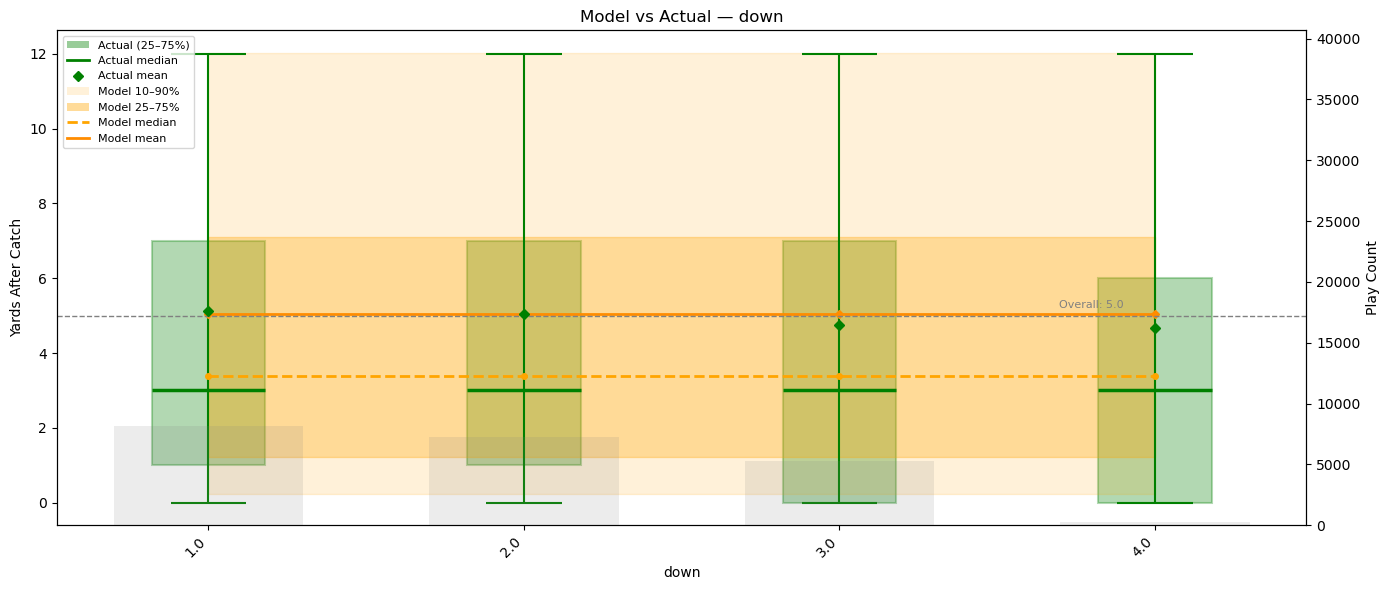

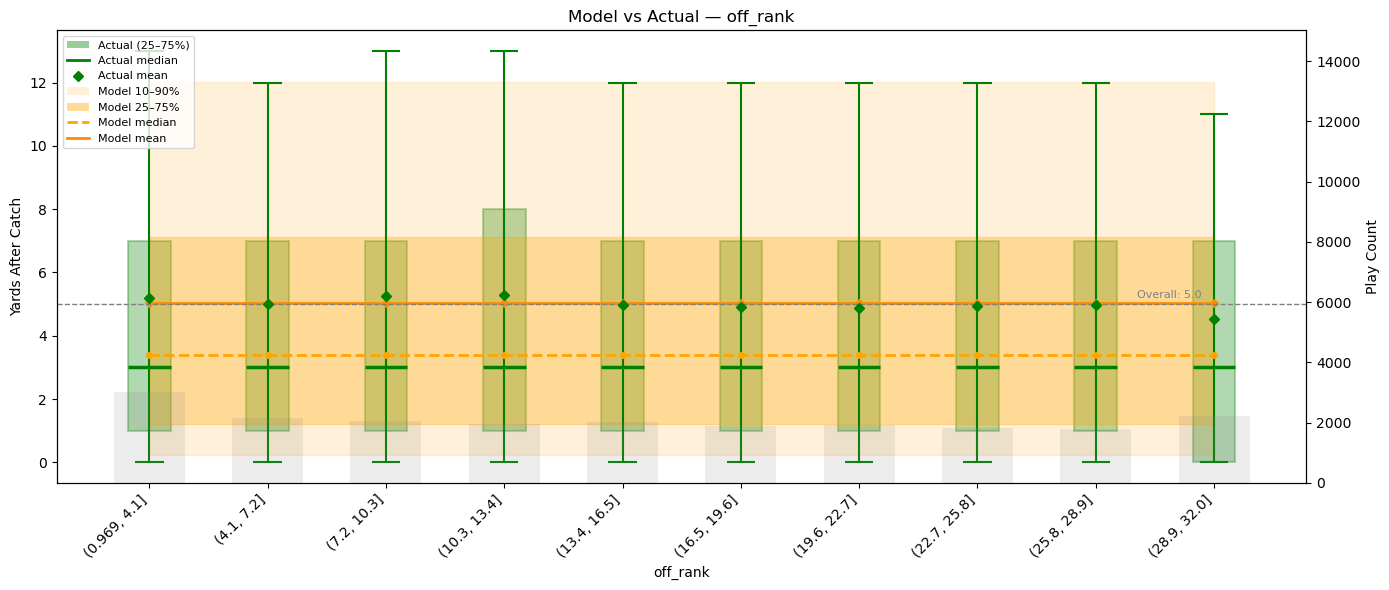

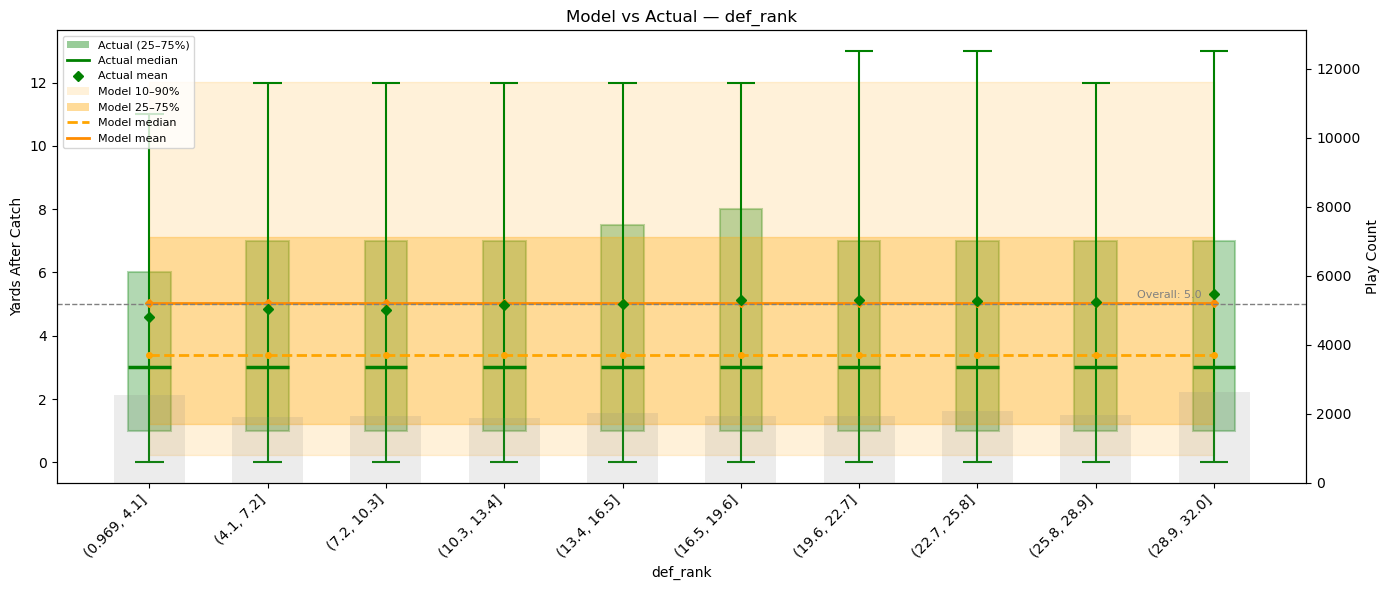

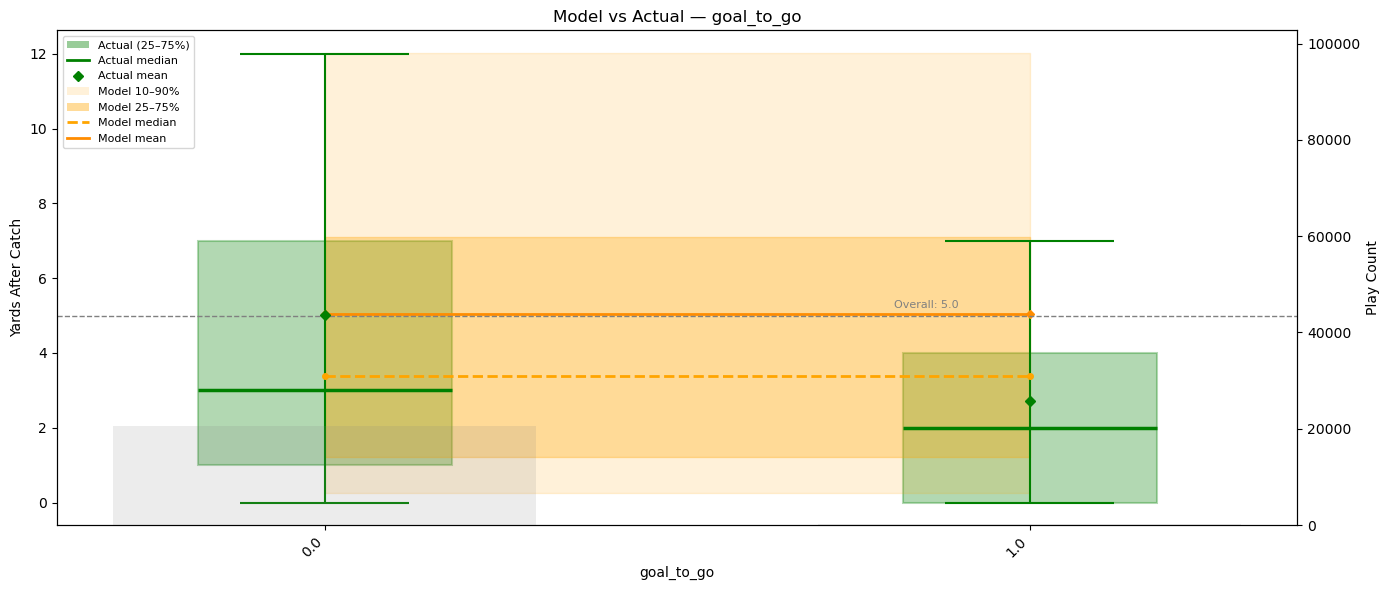

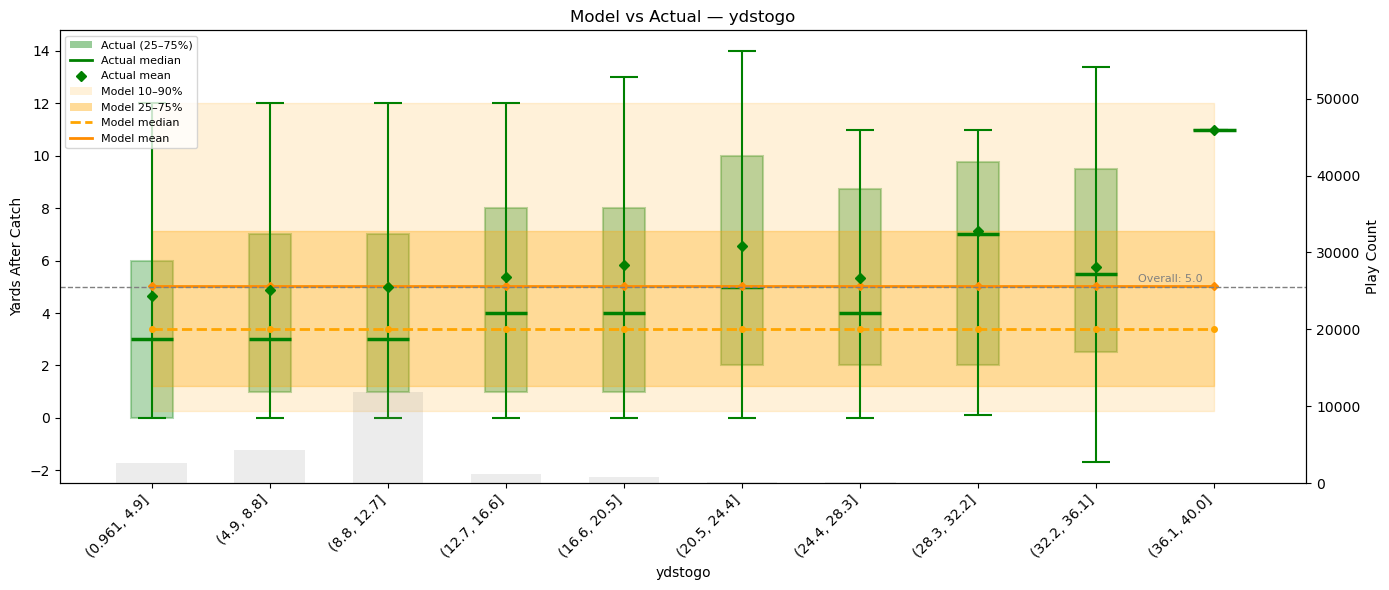

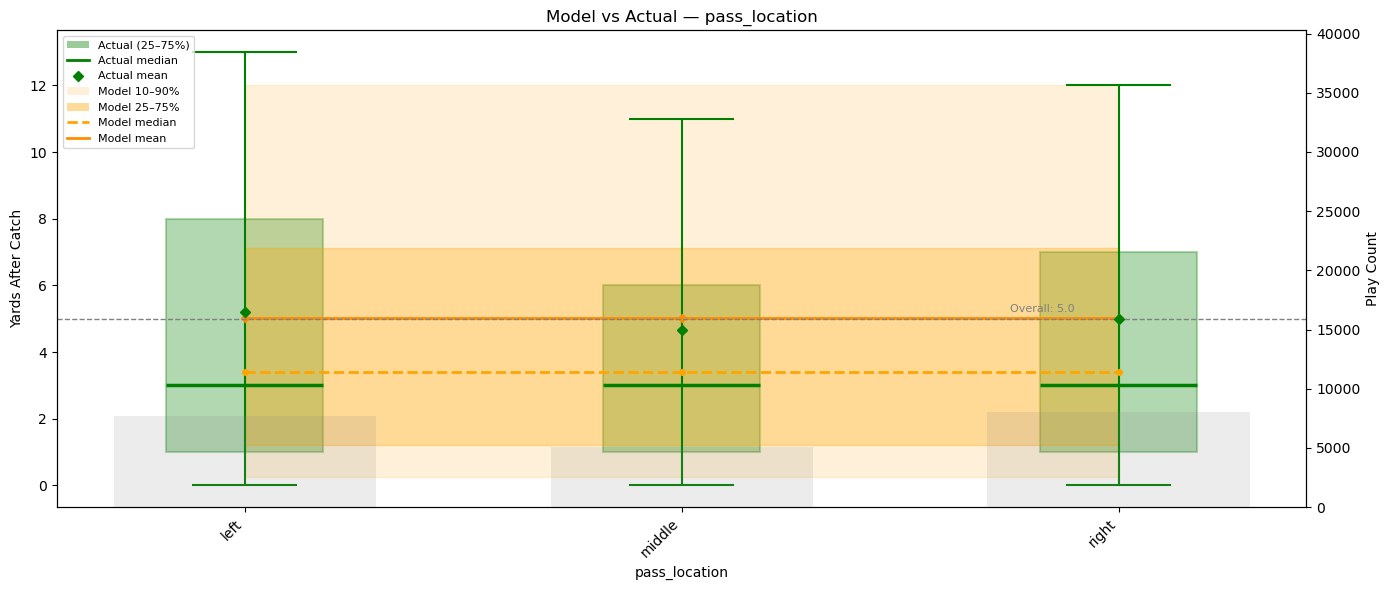

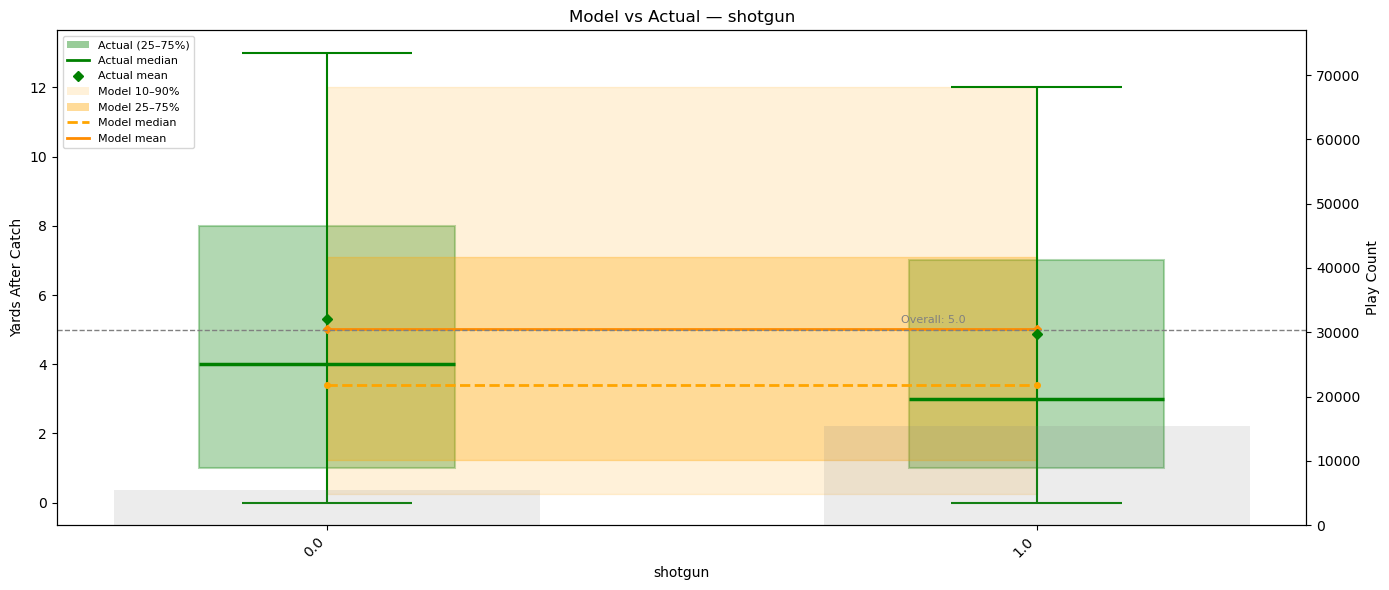

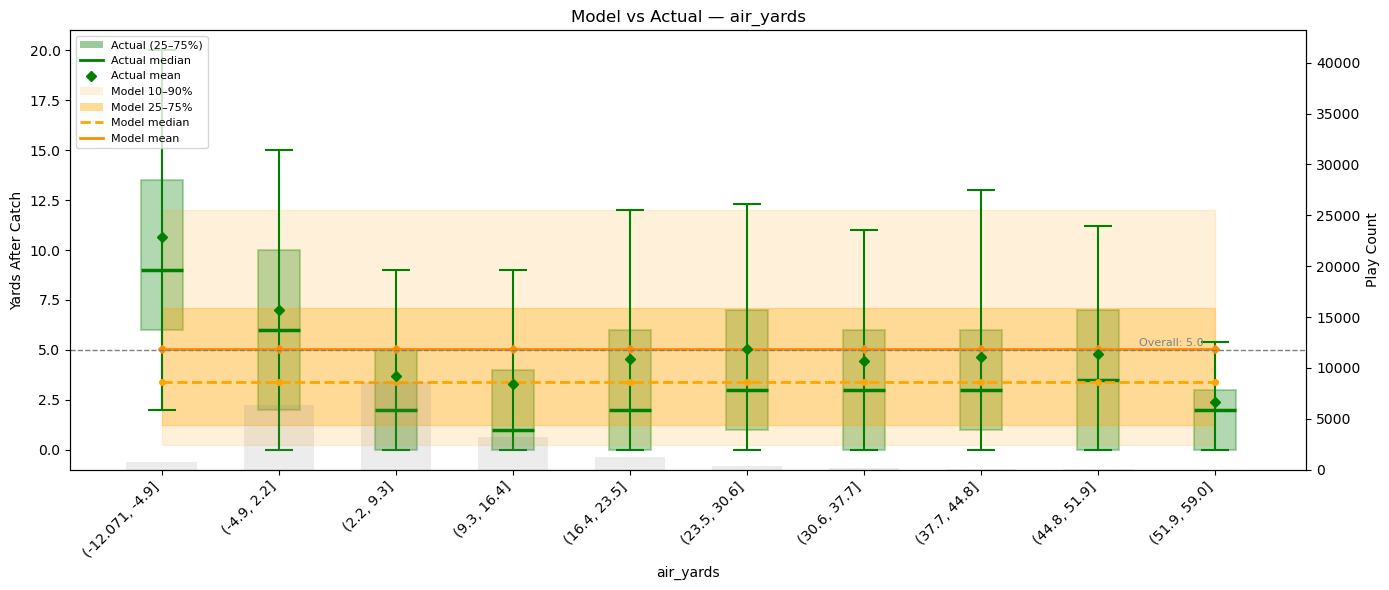

In [79]:
for f in model['features']:
    plot_model_vs_actual(model, test_df, variable=f)